In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import tools

import os
os.chdir("/home/filippos-dakis/Documents/Github_Repos/Dual-rail-Erasure-Qubits")


In [2]:
# Pauli operators
I = qt.qeye(2)
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()


II = qt.tensor(I, I)                                # two-qubit identity gate

# -------------------- Operators acting on CAVITY --------------------
X0 = qt.tensor(X, I)                                # Pauli operators acting on the cavity
Y0 = qt.tensor(Y, I)
Z0 = qt.tensor(Z, I)
# ------------------- Operators acting on TRANSMON -------------------
X1 = qt.tensor(I, X)                                # Pauli operators acting on the transmon/ancilla
Y1 = qt.tensor(I, Y)
Z1 = qt.tensor(I, Z)


N_points  = 2**12                                   # total points for curve/simulation etc


Now, we can take a break and show how square pulses can cancel $ZZ$ crosstalk (or $XX$, $YY$ crosstalks up to a rotation). We make this claim in the main text and the supplementary material so here we have an example of an $XX$ gate robust to $ZZ$ quasistatic noise to first order. For more dertails, see Section II in Supplementary Material, Eqs. (S20) - (S27).

The geometric condition is given in Eq. (S27) depicting the need for two 3D curves with orthogonal tangent components in the interval $t\in [0,T_g]$. Of course, the same condition is used for the mroe complicated $X_1\otimes Z_2$ gate derived above.

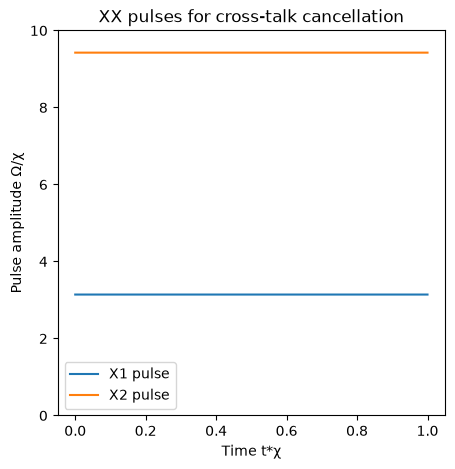

In [3]:
chi = 1.

omega_x1, omega_x2= np.loadtxt("pulses/XX_Square_pulses.csv", delimiter=",").T

t_0_1 = np.linspace(0,1, N_points)


fig = plt.figure(figsize=(5, 5))

plt.plot(t_0_1, omega_x1, label = 'X1 pulse')
plt.plot(t_0_1, omega_x2, label = 'X2 pulse')

plt.xlabel("Time t*χ")
plt.ylabel("Pulse amplitude Ω/χ")
plt.title("XX pulses for cross-talk cancellation")
plt.ylim([0,10])
plt.legend();



Test the crosstalk robustness of the XX gate

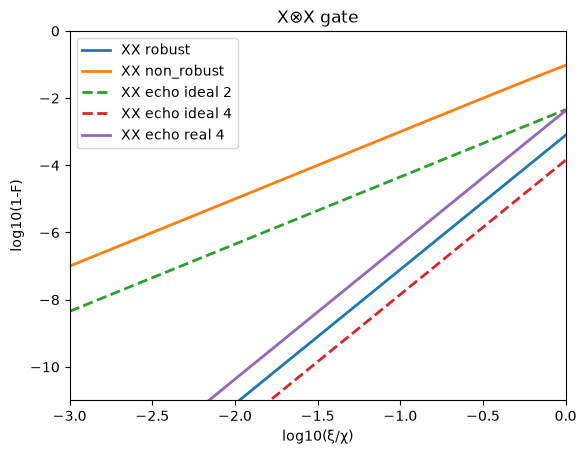

In [4]:
# normalized parameters
x_X1 = omega_x1 * chi                                             # normalized control along X-axis                                       

x_X2 = omega_x2 * chi                                             # normalized control along X-axis                                       

t_XX = np.linspace(0, 1/chi, N_points)                            # gate time

t_XX2 = np.linspace(0, 1/chi, N_points)

t_XX2_echo = np.linspace(0, 1/chi, N_points)/4

noise_points = 50

ksi = np.logspace(-3,0, noise_points)                             # noise parameter

ksi_over_chi = ksi * chi


fid_XX_robust        = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_non_robust    = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_echo_ideal_2  = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_echo_ideal_4  = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_echo_real_4   = np.zeros_like(ksi)                         # initialize array for later use

for q in range(0,noise_points):

    # ZZ robust
    H_XX_robust = [[X0/2,               x_X1],
                   [X1/2,               x_X2],
                   [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_robust = qt.QobjEvo(H_XX_robust, tlist= t_XX)           # quantum object 

    result_XX_robust = qt.propagator(H_XX_robust, t = t_XX, args=None, options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    fid_XX_robust[q] = np.abs(tools.calculate_gate_fidelity(result_XX_robust[-1], X0*X1))

    # non-robust 
    H_XX_non_robust = [[X0/2,               x_X2],
                       [X1/2,               x_X2],
                       [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_non_robust = qt.QobjEvo(H_XX_non_robust, tlist= t_XX2)           # quantum object 

    result_XX_non_robust = qt.propagator(H_XX_non_robust, t = t_XX2, args=None, 
                                         options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    fid_XX_non_robust[q] = np.abs(tools.calculate_gate_fidelity(result_XX_non_robust[-1], X0*X1))

    # non-robust with echo
    H_XX_non_rob_w_echo = [[X0/2,               x_X2],
                           [X1/2,               x_X2],
                           [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_non_rob_w_echo = qt.QobjEvo(H_XX_non_rob_w_echo, tlist= t_XX2_echo)           # quantum object 

    result_XX_non_rob_w_echo = qt.propagator(H_XX_non_rob_w_echo, t = t_XX2_echo, args=None, 
                                             options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    echo_2 = X0 * result_XX_non_rob_w_echo[-1]**2 * X0 *result_XX_non_rob_w_echo[-1]**2 # apply echo pulse

    fid_XX_echo_ideal_2[q] = np.abs(tools.calculate_gate_fidelity(echo_2, X0*X1))

    echo_4 = X0 * result_XX_non_rob_w_echo[-1] * X0 *result_XX_non_rob_w_echo[-1]
    fid_XX_echo_ideal_4[q] = np.abs(tools.calculate_gate_fidelity(echo_4**2, X0*X1))

    # non-robust with echo
    c = 1.
    H_X0_non_rob_realistic = [[X0/2,                x_X2*c],
                              [X1/2,                x_X2*0],
                              [Z0*Z1/2,    ksi_over_chi[q]]]
    
    H_X_non_rob_realistic = qt.QobjEvo(H_X0_non_rob_realistic, tlist= t_XX2/3)           # quantum object 

    result_X_non_rob_realistic = qt.propagator(H_X_non_rob_realistic, t = t_XX2/3, args=None, 
                                                options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15}) 
    
    X_0    = result_X_non_rob_realistic[-1]
    echo_4_real = X_0 * result_XX_non_rob_w_echo[-1] * X_0 *result_XX_non_rob_w_echo[-1]  # apply echo pulse

    fid_XX_echo_real_4[q] = np.abs(tools.calculate_gate_fidelity(echo_4_real**2, X0*X1))



    
fig, ax = plt.subplots()

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_robust)), linewidth = 2, label = "XX robust")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_non_robust)), linewidth = 2, label = "XX non_robust")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_echo_ideal_2)), "--", linewidth = 2, label = "XX echo ideal 2")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_echo_ideal_4)), "--", linewidth = 2, label = "XX echo ideal 4")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_echo_real_4)), linewidth = 2, label = "XX echo real 4")
ax.set_xlabel("log10(ξ/χ)")
ax.set_ylabel("log10(1-F)")
ax.set_title("X⊗X gate")
ax.set_xlim([-3, 0])
ax.set_ylim([-11, 0])
ax.legend()

fig.savefig("XX_crosstalk_robust_wrt_chi_updated.svg")

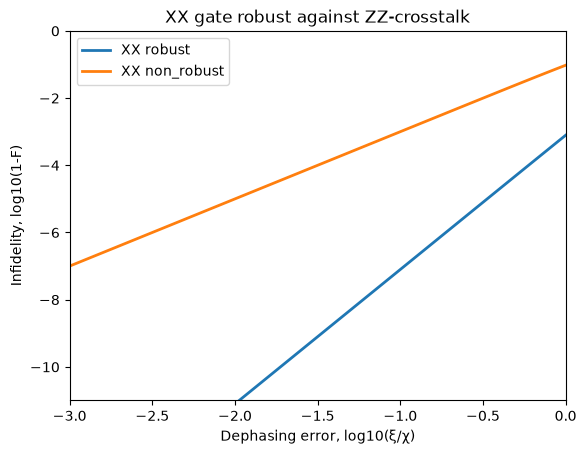

In [5]:
fig, ax = plt.subplots()

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_robust)), linewidth = 2, label = "XX robust")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_non_robust)), linewidth = 2, label = "XX non_robust")

#ax.plot(np.log10(gamma_over_chi / chi), np.log10( (gamma_over_chi/chi) **2  *8), linewidth = 2, label = "2-order")

#ax.plot(np.log10(ksi_over_chi / chi), np.log10( (ksi_over_chi/chi) **4  /1000), linewidth = 2, label = "4-order")


ax.set_xlabel("Dephasing error, log10(ξ/χ)")
ax.set_ylabel("Infidelity, log10(1-F)")
ax.set_title("XX gate robust against ZZ-crosstalk")
ax.set_ylim([-11, 0])
ax.set_xlim([-3, 0])
ax.legend();

# fig.savefig("XX_crosstalk_robust_wrt_chi.svg")

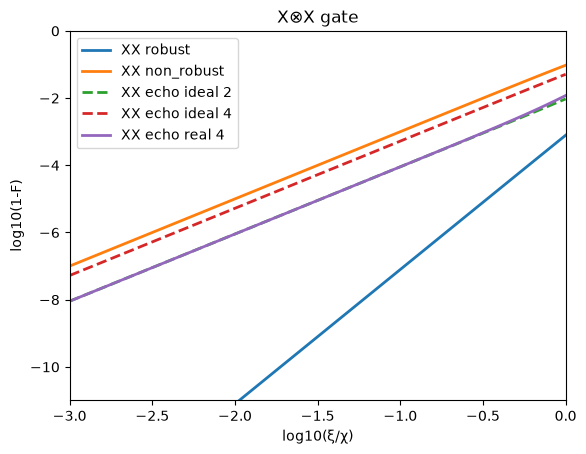

In [10]:
# normalized parameters
x_X1 = omega_x1 * chi                                             # normalized control along X-axis                                       

x_X2 = omega_x2 * chi                                             # normalized control along X-axis                                       

t_XX = np.linspace(0, 1/chi, N_points)                            # gate time

t_XX2 = np.linspace(0, 1/chi, N_points)

t_XX2_echo = np.linspace(0, 1/chi, N_points)/4

noise_points = 50

ksi = np.logspace(-3,0, noise_points)                             # noise parameter

ksi_over_chi = ksi * chi


fid_XX_robust        = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_non_robust    = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_echo_ideal_2  = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_echo_ideal_4  = np.zeros_like(ksi)                         # initialize array for later use
fid_XX_echo_real_4   = np.zeros_like(ksi)                         # initialize array for later use

for q in range(0,noise_points):

    # ZZ robust
    H_XX_robust = [[X0/2,               x_X1],
                   [X1/2,               x_X2],
                   [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_robust = qt.QobjEvo(H_XX_robust, tlist= t_XX)           # quantum object 

    result_XX_robust = qt.propagator(H_XX_robust, t = t_XX, args=None, options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    fid_XX_robust[q] = np.abs(tools.calculate_gate_fidelity(result_XX_robust[-1], X0*X1))

    # non-robust 
    H_XX_non_robust = [[X0/2,               x_X2],
                       [X1/2,               x_X2],
                       [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_non_robust = qt.QobjEvo(H_XX_non_robust, tlist= t_XX2)           # quantum object 

    result_XX_non_robust = qt.propagator(H_XX_non_robust, t = t_XX2, args=None, 
                                         options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    fid_XX_non_robust[q] = np.abs(tools.calculate_gate_fidelity(result_XX_non_robust[-1], X0*X1))

    # non-robust with echo
    H_XX_non_rob_w_echo = [[X0/2,               x_X2],
                           [X1/2,               x_X2],
                           [Z1/2, ksi_over_chi[q]]]
    
    H_XX_non_rob_w_echo = qt.QobjEvo(H_XX_non_rob_w_echo, tlist= t_XX2_echo)           # quantum object 

    result_XX_non_rob_w_echo = qt.propagator(H_XX_non_rob_w_echo, t = t_XX2_echo, args=None, 
                                             options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    echo_2 = X1 * result_XX_non_rob_w_echo[-1]**2 * X1 *result_XX_non_rob_w_echo[-1]**2 # apply echo pulse

    fid_XX_echo_ideal_2[q] = np.abs(tools.calculate_gate_fidelity(echo_2, X0*X1))

    echo_4 = X1 * result_XX_non_rob_w_echo[-1] * X1 *result_XX_non_rob_w_echo[-1]
    fid_XX_echo_ideal_4[q] = np.abs(tools.calculate_gate_fidelity(echo_4**2, X0*X1))

    # non-robust with echo
    c = 1.
    H_X0_non_rob_realistic = [[X0/2,                x_X2*0],
                              [X1/2,                x_X2*c],
                              [Z1/2,    ksi_over_chi[q]]]
    
    H_X_non_rob_realistic = qt.QobjEvo(H_X0_non_rob_realistic, tlist= t_XX2/3)           # quantum object 

    result_X_non_rob_realistic = qt.propagator(H_X_non_rob_realistic, t = t_XX2/3, args=None, 
                                                options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15}) 
    
    X_1    = result_X_non_rob_realistic[-1]
    echo_4_real = X_1 * result_XX_non_rob_w_echo[-1] * X_1 *result_XX_non_rob_w_echo[-1]  # apply echo pulse

    fid_XX_echo_real_4[q] = np.abs(tools.calculate_gate_fidelity(echo_4_real**2, X0*X1))



    
fig, ax = plt.subplots()

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_robust)), linewidth = 2, label = "XX robust")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_non_robust)), linewidth = 2, label = "XX non_robust")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_echo_ideal_2)), "--", linewidth = 2, label = "XX echo ideal 2")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_echo_ideal_4)), "--", linewidth = 2, label = "XX echo ideal 4")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_echo_real_4)), linewidth = 2, label = "XX echo real 4")
ax.set_xlabel("log10(ξ/χ)")
ax.set_ylabel("log10(1-F)")
ax.set_title("X⊗X gate")
ax.set_xlim([-3, 0])
ax.set_ylim([-11, 0])
ax.legend()

fig.savefig("XX_crosstalk_robust_wrt_chi_updated.svg")